In [1]:
import pandas as pd
import pickle
from tqdm.notebook import tqdm
import torch
import os
from sklearn.metrics import silhouette_score
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, silhouette_score
import numpy as np
from sklearn.decomposition import PCA
# import umap.umap_ as umap
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix

In [2]:
with open("/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/enzyme_task/data_for_temp/gids_intersecting_with_bacdive.pkl", "rb") as f:
    gids_for_data = pickle.load(f)

with open("/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/enzyme_task/data_for_temp/ec_dict.pkl", 'rb') as f:
    ec_dict = pickle.load(f)

enzyme_df = pd.read_csv("/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/data/bacdive_dataset_fetch/bacdive_dataset/train_test_enzymes.csv")

In [3]:
enzyme_df

,Genome_ID,urease,gelatinase,ornithine decarboxylase,lysine decarboxylase,beta-galactosidase,beta-glucuronidase,catalase,cytochrome oxidase,oxidase,...,valine aminopeptidase,cystine aminopeptidase,tryptophan decarboxylase,hyaluronidase,ribonuclease,alpha-glucuronidase,alanine aminopeptidase,benzoyl-D-arginine arylamidase,hippurate hydrolase,hyaluronate lyase
0,GCF_000010485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GCF_000010385,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GCF_000007445,-,-,+,+,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GCF_000006945,-,-,+,+,-,-,+,-,-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GCF_000023365,-,-,-,-,+,+,+,-,-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3032,GCF_902459475,NaN,NaN,NaN,NaN,-,-,-,NaN,-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3033,GCF_001457455,-,-,NaN,NaN,-,-,+,NaN,-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3034,GCF_900637395,-,NaN,NaN,NaN,-,-,-,NaN,+,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3035,GCF_937425535,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
def search_for_ec_in_gid(gid, query_ec):
    fasta_name = f"sorted_{gid}"
    csv_path = f"/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/enzyme_task/CLEAN/app/results/inputs/{fasta_name}.csv"
    df = pd.read_csv(csv_path)

    df['ec_entries'] = df.iloc[:, 2].str.split(';')
    df_exploded = df.explode('ec_entries')
    df_exploded[['ec', 'dist']] = df_exploded['ec_entries'].str.split('/', expand=True).apply(lambda x: x.str.strip())

    match = df_exploded[df_exploded['ec'] == query_ec]
    if not match.empty:
        row = match.iloc[0]
        return True, row.iloc[1], float(row['dist'])
    return False, None, None

def run_ec_search(enzyme_df, ec_dict, specific_col=None, specific_gid=None, sign=None):
    cols_to_process = [specific_col] if specific_col else enzyme_df.columns[1:]
    results = {}

    for col in tqdm(cols_to_process, desc="Processing columns"):
        try:
            query_ec = 'EC:' + ec_dict[col]
        except KeyError:
            print(f"EC number not found for enzyme: {col}")
            continue

        sub_df = enzyme_df[enzyme_df[col].notna()][['Genome_ID', col]]#.drop_duplicates(subset='Genome_ID')
        if specific_gid:
            sub_df = sub_df[sub_df['Genome_ID'] == specific_gid]

        pos_count, neg_count = 0, 0
        pos_p_acc, neg_p_acc = [], []
        pos_gids, neg_gids = [], []
        no_causal_pos, no_causal_neg = 0, 0
        pos_available, neg_available = 0, 0

        for gid, val in tqdm(zip(sub_df.Genome_ID, sub_df[col]), total=len(sub_df), desc=f"Searching ECs for {col}", leave=False):
            if ('+' not in val and '-' not in val) or (sign and sign not in val):
                continue
            try:
                flag, p_acc, dist = search_for_ec_in_gid(gid, query_ec)
                if '+' in val and (not sign or sign == '+'):
                    pos_available += 1
                    if flag:
                        pos_count += 1
                        pos_p_acc.append(p_acc)
                        pos_gids.append(gid)
                    else:
                        no_causal_pos+=1
                elif '-' in val and (not sign or sign == '-'):
                    neg_available += 1
                    if flag:
                        neg_count += 1
                        neg_p_acc.append(p_acc)
                        neg_gids.append(gid)
                    else:
                        no_causal_neg+=1
            except FileNotFoundError as e:
                if specific_gid:
                    raise e
                continue

        results[col] = {
            "usable": 0.8 <= (pos_count / neg_count) <= 1.2 if neg_count else False,
            "positive": {
                "count": pos_count,
                "available": pos_available,
                "no_causal_positive_activity":no_causal_pos,
                "gids": pos_gids,
                "p_acc": pos_p_acc,
            },
            "negative": {
                "count": neg_count,
                "available": neg_available,
                "no_causal_negative_activity":no_causal_neg,
                "gids": neg_gids,
                "p_acc": neg_p_acc,
            },
        }
        print(f"{col} | +: {pos_count}/{pos_available}, +_no_causal: {no_causal_pos}/{pos_available}, -: {neg_count}/{neg_available}, -_no_causal: {no_causal_neg}/{neg_available} | usable: {results[col]['usable']}")
        #denom = (pos_available - pos_count) + (neg_available - neg_count)
        #num = pos_available

    return results

def get_order(gid, max_len=2250):
    #make sure we read only those proteins whose length is less than 2250
    fasta_path = f'/orange/juannanzhou/bacteria_genome/protein_faa_files/sorted_protein_faa_files/sorted_{gid}.faa'
    ids = []
    try:
        with open(fasta_path) as f:
            cur_id, cur_seq = None, []
            for line in f:
                line = line.strip()
                if line.startswith(">"):
                    # flush previous record
                    if cur_id is not None and len("".join(cur_seq)) <= max_len:
                        ids.append(cur_id)
                    cur_id = line[1:].split()[0]
                    cur_seq = []
                else:
                    cur_seq.append(line)
            # flush last record
            if cur_id is not None and len("".join(cur_seq)) <= max_len:
                ids.append(cur_id)
    except Exception as e:
        print(f"Error reading {fasta_path}: {e}")
        return None
    return ids

def get_index(gid, p_acc):
    ids = get_order(gid)
    index = ids.index(p_acc) if p_acc in ids else None
    return ids, index

def get_embedding(gid, p_acc, emb_type='blm_big', window_length=0):
    ids_in_complete_genome, index = get_index(gid, p_acc)

    # Skip if index itself is outside first 5000
    if index >= 5000:
        print(f"[SKIP] gid={gid}, index={index} (>=5000) -> skipping embedding.")
        return None

    if emb_type in ('blm_big', 'blm_small'):
        parent_dir = {
            'blm_big': "/orange/juannanzhou/bacteria_genome/bacdive_genome_embeddings_bpt_large",
            'blm_small': "/orange/juannanzhou/bacteria_genome/bacdive_genome_embeddings",
        }[emb_type]
        emb = torch.load(os.path.join(parent_dir, f"{gid}_blm_all_layers.pt"),
                         map_location=torch.device('cpu'))  # [L, N, 480]

        start = max(0, index - window_length)
        end = min(min(emb.shape[1], 5000), index + window_length + 1)
        if end < index + window_length + 1:
            print(f"[TRUNCATE] gid={gid}, index={index}, window=({start}:{end}), capped at 5000")
        emb = emb[:, start:end, :].mean(1).cpu()  # [L, 480]

    elif emb_type == 'esm':
        parent_dir = "/orange/juannanzhou/bacteria_genome/protein_faa_files/sorted_esm_embeds/480_dim"
        emb = torch.load(os.path.join(parent_dir, f"mean_sorted_{gid}.pt"),
                         map_location=torch.device('cpu'))  # [N, 480]

        start = max(0, index - window_length)
        end = min(min(emb.shape[0], 5000), index + window_length + 1)
        if end < index + window_length + 1:
            print(f"[TRUNCATE] gid={gid}, index={index}, window=({start}:{end}), capped at 5000")
        emb = emb[start:end, :].mean(0, keepdim=True)  # [1, 480]

    else:
        raise ValueError(f"WRONG MODEL NAME ENTERED --> {emb_type}")

    return emb  # [L,480] for blm_*; [1,480] for esm

def get_clustering_dataset_all_layers(gids, p_accs, label, emb_type='blm_big', window_length=0):
    embs, labels = [], []
    for gid, p_acc in tqdm(list(zip(gids, p_accs)), desc=f"Building dataset for {emb_type} {label}", leave=False):
        try:
            emb = get_embedding(gid, p_acc, emb_type, window_length=window_length)
            if emb is None:
                print(f"[SKIP] gid={gid}, no embedding returned.")
                continue
            embs.append(emb)   # [L, D] or [1, D]
            labels.append(label)
        except Exception as ex:
            tqdm.write(f"[ERROR] gid={gid}, reason={ex}")
            continue

    if len(embs) == 0:
        raise ValueError(f"No embeddings collected for {emb_type} label={label}")

    return torch.stack(embs), labels  # [N, L, D]


def cluster_all_layers(result, trait, emb_type='blm_big', window_length=0):
    pos_gids = result[trait]['positive']['gids']
    pos_p_acc = result[trait]['positive']['p_acc']
    neg_gids = result[trait]['negative']['gids']
    neg_p_acc = result[trait]['negative']['p_acc']

    e_pos, l_pos = get_clustering_dataset_all_layers(pos_gids, pos_p_acc, 1, emb_type, window_length = window_length)
    e_neg, l_neg = get_clustering_dataset_all_layers(neg_gids, neg_p_acc, 0, emb_type, window_length = window_length)

    e_all = torch.cat([e_pos, e_neg], dim=0)  # shape: [N, L, D]
    l_all = l_pos + l_neg                     # same labels for all layers
    
    def get_layer(layer_idx):
        return e_all[:, layer_idx, :], l_all  # returns single layer embeddings & labels

    return get_layer, e_all.shape[1], [len(l_pos), len(l_neg)]



def find_and_evaluate_best_layer(get_layer, n_layers, labels, no_causal_labels=None, test_size=0.2, random_state=42):
    sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    for train_idx, test_idx in sss.split(np.zeros(len(labels)), labels):
        pass

    best_score, best_layer, best_C = -np.inf, None, None
    for layer in range(n_layers):
        X, y = get_layer(layer)
        X = X.numpy() if hasattr(X, "numpy") else X
        y = np.array(y)
        X_train, y_train = X[train_idx], y[train_idx]
        grid = GridSearchCV(
            LogisticRegression(penalty="l2", solver="liblinear", max_iter=1000),
            {"C": np.logspace(-3, 3, 10)},
            cv=3,
            scoring="f1"
        )
        grid.fit(X_train, y_train)
        if grid.best_score_ > best_score:
            best_score, best_layer, best_C = grid.best_score_, layer, grid.best_params_["C"]

    X, y = get_layer(best_layer)
    X = X.numpy() if hasattr(X, "numpy") else X
    y = np.array(y)
    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    model = LogisticRegression(penalty="l2", solver="liblinear", max_iter=1000, C=best_C)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    F1_original = f1_score(y_test, y_pred)
    acc_original = (tp + tn) / (tp + tn + fp + fn)

    if no_causal_labels is not None:
        no_causal_labels = np.array(no_causal_labels)
        fn_inf = fn + np.sum(no_causal_labels == 1)
        tn_inf = tn + np.sum(no_causal_labels == 0)
        tp_inf = tp
        fp_inf = fp
        precision = tp_inf / (tp_inf + fp_inf) if (tp_inf + fp_inf) > 0 else 0
        recall = tp_inf / (tp_inf + fn_inf) if (tp_inf + fn_inf) > 0 else 0
        F1_inflated = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        acc_inflated = (tp_inf + tn_inf) / (tp_inf + tn_inf + fp_inf + fn_inf)
    else:
        F1_inflated = None
        acc_inflated = None
        tp_inf, tn_inf, fp_inf, fn_inf = None, None, None, None

    return {
        "layer": best_layer,
        "best_C": best_C,
        "F1_original": F1_original,
        "F1_inflated": F1_inflated,
        "AUROC": roc_auc_score(y_test, y_proba),
        "accuracy_original": acc_original,
        "accuracy_inflated": acc_inflated,
        "silhouette": silhouette_score(X, y),
        "TP_original": tp,
        "TN_original": tn,
        "FP_original": fp,
        "FN_original": fn,
        "TP_inflated": tp_inf,
        "TN_inflated": tn_inf,
        "FP_inflated": fp_inf,
        "FN_inflated": fn_inf,
    }



def group_by_metric(results_df, metric='silhouette'):
    # Drop rows where BOTH num_pos and num_neg are < 10
    # results_df = results_df[~((results_df["num_pos"] < 10) & (results_df["num_neg"] < 10))]
    results_df = results_df[(results_df['num_pos'] > 10) & (results_df['num_neg'] > 10)]
    best_results = (
        results_df.loc[results_df.groupby(["trait", "model"])[metric].idxmax()]
        .reset_index(drop=True)
    )
    
    # Pivot for metric values
    wide = (
        best_results.pivot(index="trait", columns="model", values=metric)
        .rename(columns=lambda m: f"{m}_{metric}")
        .reset_index()
    )
    
    # Pivot for std values (if available)
    std_col = f"{metric}_std" if f"{metric}_std" in best_results.columns else None
    if std_col and std_col in best_results.columns:
        wide_std = (
            best_results.pivot(index="trait", columns="model", values=std_col)
            .rename(columns=lambda m: f"{m}_{metric}_std")
            .reset_index(drop=True)
        )
        wide = pd.concat([wide, wide_std], axis=1)
    
    # Check if 'layer' column exists
    has_layer = 'layer' in best_results.columns
    
    if has_layer:
        best = (
            best_results.loc[
                best_results.groupby("trait")[metric].idxmax(),
                ["trait", "model", "layer", "num_pos", "num_neg"]
            ]
            .rename(columns={"model": "best_model"})
        )
        out = wide.merge(best, on="trait")
        # Ensure consistent column ordering
        out = out[["trait", "best_model", "layer"] + [c for c in out.columns if c not in {"trait", "best_model", "layer"}]]
    else:
        best = (
            best_results.loc[
                best_results.groupby("trait")[metric].idxmax(),
                ["trait", "model", "num_pos", "num_neg"]
            ]
            .rename(columns={"model": "best_model"})
        )
        out = wide.merge(best, on="trait")
        # Ensure consistent column ordering (without layer)
        out = out[["trait", "best_model"] + [c for c in out.columns if c not in {"trait", "best_model"}]]
    
    # Sort by difference between blm_big and esm
    blm_col = f"blm_big_{metric}"
    esm_col = f"esm_{metric}"
    if blm_col in out.columns and esm_col in out.columns:
        try:
            out = out.assign(diff=abs(out[blm_col]) - abs(out[esm_col])).sort_values("diff", ascending=False).drop(columns="diff")
        except TypeError as e:
            raise TypeError(f"Error calculating difference between {blm_col} and {esm_col}: {e}")
    return out

def plot_embeddings(matrix, labels, trait, n_neighbors=15, min_dist=0.1, 
                    random_state=42, balance=True, model_name=None, plot=True, 
                    pca_only=False, ax=None, color_map=None):
    # Convert tensor if needed
    if isinstance(matrix, torch.Tensor):
        matrix = matrix.cpu().numpy()
    
    # Balance classes
    if balance:
        rng = np.random.default_rng(random_state)
        label_counts = Counter(labels)
        min_count = min(label_counts.values())
        balanced_idx = np.hstack([
            rng.choice(np.where(np.array(labels) == lbl)[0], min_count, replace=False)
            for lbl in label_counts
        ])
        matrix, labels = matrix[balanced_idx], np.array(labels)[balanced_idx]
    
    # Compute PCA
    pca = PCA(n_components=2, random_state=random_state)
    pca_2d = pca.fit_transform(matrix)
    var_exp = pca.explained_variance_ratio_.sum() * 100
    sil_pca = silhouette_score(pca_2d, labels)
    
    # PCA-only path
    if pca_only:
        if plot:
            if ax is None:
                fig, ax = plt.subplots(figsize=(4, 3), dpi=150)
            if color_map is None:
                unique_labels = sorted(set(labels))
                colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
                color_map = {lbl: col for lbl, col in zip(unique_labels, colors)}
            
            ax.scatter(pca_2d[:, 0], pca_2d[:, 1],
                      c=[color_map[int(x)] for x in labels],
                      alpha=0.6, s=50, edgecolor="k", linewidth=0.3)
            ax.set_xlabel("PC1")
            ax.set_ylabel("PC2")
            # Don't set title here - let the caller do it with the stats returned
        return sil_pca, var_exp  # Return both stats
    
    # Full PCA + UMAP path
    umap_2d = umap.UMAP(n_components=2, n_neighbors=n_neighbors, 
                        min_dist=min_dist, random_state=random_state).fit_transform(matrix)
    sil_umap = silhouette_score(umap_2d, labels)
    
    if plot:
        unique_labels = sorted(set(labels))
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
        color_map = {lbl: col for lbl, col in zip(unique_labels, colors)}
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)
        fig.suptitle(f"{trait}: {model_name}", fontsize=16, fontweight="bold")
        
        for ax, (name, proj, sil) in zip(axes, 
            [("PCA", pca_2d, sil_pca), ("UMAP", umap_2d, sil_umap)]):
            ax.scatter(proj[:, 0], proj[:, 1],
                      c=[color_map[l] for l in labels],
                      alpha=0.6, s=50, edgecolor="k", linewidth=0.3)
            
            if name == "PCA":
                ax.set_xlabel("PC1")
                ax.set_ylabel("PC2")
                ax.set_title(f"PCA ({var_exp:.1f}% var) | Sil={sil:.3f}", fontsize=12)
            else:
                ax.set_xticks([])
                ax.set_yticks([])
                ax.set_title(f"UMAP | Sil={sil:.3f}", fontsize=12)
        
        handles = [plt.Line2D([], [], marker='o', linestyle='', color=color_map[l],
                             alpha=0.7, markersize=8) for l in unique_labels]
        fig.legend(handles, [str(l) for l in unique_labels],
                  loc="upper right", title="Classes", fontsize=10)
        plt.tight_layout(rect=[0, 0, 0.9, 1])
        plt.show()
    
    return sil_pca, sil_umap

def aggregate_results_by_model(results_df):
    try:
        # Group by trait, num_pos, num_neg, and model
        grouped = results_df.groupby(['trait', 'num_pos', 'num_neg', 'model']).agg({
            'F1': ['mean', 'std']
        }).reset_index()
        
        # Flatten column names
        grouped.columns = ['trait', 'num_pos', 'num_neg', 'model', 'F1', 'F1_std']
        
        return grouped
    
    except KeyError as e:
        raise KeyError(f"Required column not found in dataframe: {e}")
    except Exception as e:
        raise Exception(f"Error aggregating results: {e}")
        
def gene_presence_only_metrics(num_pos, pos_available, num_neg, neg_available):
    """
    You’re measuring how well gene presence alone explains enzyme activity.

    a)Precision tells you: given that a genome has the enzyme gene, how often does it actually show activity?

    b)F1 tells you: how good this simple “gene → activity” rule is overall, combining how many true actives it catches and how many false activations it produces.

    It’s a baseline to see how much real biology is missing when you rely only on the causal gene."""
    TP = num_pos
    FP = num_neg
    FN = pos_available - num_pos

    # precision = P(active | enzyme present)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0

    # recall = P(predicted active | true active)
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    # F1 using the above precision & recall
    f1 = 0.0 if (precision + recall) == 0 else 2 * precision * recall / (precision + recall)

    return precision, f1

def get_inflated_labels(r, trait):
    labels = [1]*r[trait]['positive']['no_causal_positive_activity']+[0]*r[trait]['negative']['no_causal_negative_activity']
    return labels

def sample_inflated_labels(r, trait, seed=42):
    labels = np.array(get_inflated_labels(r, trait))

    counts = np.bincount(labels)
    if counts.min() < 2:
        return labels.tolist()

    test_size = 0.2 if counts.min() >= 2 else 0.1

    sss = StratifiedShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=seed
    )

    for _, idx in sss.split(np.zeros(len(labels)), labels):
        return labels[idx].tolist()


In [ ]:
#active_genomes/genomes without causal gene


In [4]:
# r = run_ec_search(enzyme_df, ec_dict)

Processing columns:   0%|          | 0/110 [00:00<?, ?it/s]

Searching ECs for urease:   0%|          | 0/1366 [00:00<?, ?it/s]

urease | +: 298/305, +_no_causal: 7/305, -: 789/1061, -_no_causal: 272/1061 | usable: False
EC number not found for enzyme: gelatinase


Searching ECs for ornithine decarboxylase:   0%|          | 0/766 [00:00<?, ?it/s]

ornithine decarboxylase | +: 39/117, +_no_causal: 78/117, -: 140/649, -_no_causal: 509/649 | usable: False


...

benzoyl-D-arginine arylamidase | +: 0/0, +_no_causal: 0/0, -: 0/1, -_no_causal: 1/1 | usable: False


Searching ECs for hippurate hydrolase:   0%|          | 0/1 [00:00<?, ?it/s]

hippurate hydrolase | +: 0/0, +_no_causal: 0/0, -: 0/1, -_no_causal: 1/1 | usable: False


Searching ECs for hyaluronate lyase:   0%|          | 0/1 [00:00<?, ?it/s]

hyaluronate lyase | +: 0/0, +_no_causal: 0/0, -: 0/1, -_no_causal: 1/1 | usable: False


In [5]:
# with open("/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/enzyme_task/results/r_enzyme_object_no_causal_includedv2.pkl", "wb") as f:
    # pickle.dump(r, f)

In [4]:
with open("/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/enzyme_task/results/r_enzyme_object_no_causal_includedv2.pkl", "rb") as f:
    r = pickle.load(f)


In [ ]:
#single seed - 42
results_summary = []
window_length=0
for trait in tqdm(list(r.keys()), desc="Processing traits"):
    for model in ["esm", "blm_big","blm_small"]:
        try:
            get_layer, n_layers, [num_pos, num_neg] = cluster_all_layers(r, trait, model, window_length = window_length)
            all_labels = get_layer(0)[1]
            metrics = find_and_evaluate_best_layer(get_layer, n_layers, all_labels)
            results_summary.append({
                "trait": trait,
                "num_pos": num_pos,
                "num_neg": num_neg,
                "model": model,
                **metrics
            })
        except Exception as e:
            tqdm.write(f"Error processing {trait} with model {model}: {e}")

results_df = pd.DataFrame(results_summary)
# results_df.to_csv(
#     "/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/enzyme_task/data_for_temp/window0_cv_best_layer_results_with_probe.csv",
#     index=None
# )


In [ ]:
#multiple seed
results_summary = []
window_length = 0
seeds = [420, 123, 456, 789, 2025]  # Define your seeds
output_path = "/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/enzyme_task/data_for_temp/window0_cv_best_layer_results_with_probe_multipleseeds_confusion_matrix_test20_inflated.csv"

for seed in tqdm(seeds, desc="Processing seeds"):
    for trait in tqdm(list(r.keys()), desc=f"Traits (seed={seed})", leave=False):
        for model in ["esm", "blm_big", "blm_small"]:
            try:
                get_layer, n_layers, [num_pos, num_neg] = cluster_all_layers(
                    r, trait, model, window_length=window_length
                )
                all_labels = get_layer(0)[1]
                no_causal_labels = sample_inflated_labels(r, trait, seed=seed)
                metrics = find_and_evaluate_best_layer(
                    get_layer, n_layers, all_labels, no_causal_labels=no_causal_labels, random_state=seed,test_size=0.2
                )
                results_summary.append({
                    "seed": seed,
                    "trait": trait,
                    "num_pos": num_pos,
                    "num_neg": num_neg,
                    "model": model,
                    **metrics
                })
            except ValueError as e:
                tqdm.write(f"ValueError processing {trait} with model {model} (seed={seed}): {e}")
                continue
            except KeyError as e:
                tqdm.write(f"KeyError processing {trait} with model {model} (seed={seed}): {e}")
                continue
            except Exception as e:
                tqdm.write(f"Unexpected error processing {trait} with model {model} (seed={seed}): {e}")
                continue
    
    # Save after each seed completes
    results_df = pd.DataFrame(results_summary)
    results_df.to_csv(output_path, index=False)
    tqdm.write(f"Saved results after seed {seed} - Total rows: {len(results_df)}")

# Final save (redundant but ensures final state is saved)
results_df = pd.DataFrame(results_summary)
results_df.to_csv(output_path, index=False)

Processing seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Traits (seed=420):   0%|          | 0/64 [00:00<?, ?it/s]

Building dataset for esm 1:   0%|          | 0/298 [00:00<?, ?it/s]

Building dataset for esm 0:   0%|          | 0/789 [00:00<?, ?it/s]

[SKIP] gid=GCF_000024345, index=6035 (>=5000) -> skipping embedding.
[SKIP] gid=GCF_000024345, no embedding returned.
[SKIP] gid=GCF_000758705, index=5112 (>=5000) -> skipping embedding.
[SKIP] gid=GCF_000758705, no embedding returned.
[SKIP] gid=GCF_002119445, index=5010 (>=5000) -> skipping embedding.
[SKIP] gid=GCF_002119445, no embedding returned.
[SKIP] gid=GCF_002119445, index=5010 (>=5000) -> skipping embedding.
[SKIP] gid=GCF_002119445, no embedding returned.
[SKIP] gid=GCF_025264625, index=5383 (>=5000) -> skipping embedding.
[SKIP] gid=GCF_025264625, no embedding returned.


...

ValueError processing hyaluronate lyase with model blm_small (seed=123): No embeddings collected for blm_small label=1
Saved results after seed 123 - Total rows: 192


Traits (seed=456):   0%|          | 0/64 [00:00<?, ?it/s]

Building dataset for esm 1:   0%|          | 0/298 [00:00<?, ?it/s]

Building dataset for esm 0:   0%|          | 0/789 [00:00<?, ?it/s]

[SKIP] gid=GCF_000024345, index=6035 (>=5000) -> skipping embedding.
[SKIP] gid=GCF_000024345, no embedding returned.
[SKIP] gid=GCF_000758705, index=5112 (>=5000) -> skipping embedding.
[SKIP] gid=GCF_000758705, no embedding returned.
[SKIP] gid=GCF_002119445, index=5010 (>=5000) -> skipping embedding.
[SKIP] gid=GCF_002119445, no embedding returned.
[SKIP] gid=GCF_002119445, index=5010 (>=5000) -> skipping embedding.
[SKIP] gid=GCF_002119445, no embedding returned.
[SKIP] gid=GCF_025264625, index=5383 (>=5000) -> skipping embedding.
[SKIP] gid=GCF_025264625, no embedding returned.


In [54]:
#multiple seed #window length 2 (index +-2)
results_summary = []
window_length = 2
seeds = [420, 123, 456, 789, 2025]  # Define your seeds
output_path = "/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/enzyme_task/data_for_temp/window2_cv_best_layer_results_with_probe_multipleseeds_confusion_matrix.csv"

for seed in tqdm(seeds, desc="Processing seeds"):
    for trait in tqdm(list(r.keys()), desc=f"Traits (seed={seed})", leave=False):
        for model in ["esm"]:
            try:
                get_layer, n_layers, [num_pos, num_neg] = cluster_all_layers(
                    r, trait, model, window_length=window_length
                )
                all_labels = get_layer(0)[1]
                metrics = find_and_evaluate_best_layer(
                    get_layer, n_layers, all_labels, random_state=seed
                )
                results_summary.append({
                    "seed": seed,
                    "trait": trait,
                    "num_pos": num_pos,
                    "num_neg": num_neg,
                    "model": model,
                    **metrics
                })
            except ValueError as e:
                tqdm.write(f"ValueError processing {trait} with model {model} (seed={seed}): {e}")
                continue
            except KeyError as e:
                tqdm.write(f"KeyError processing {trait} with model {model} (seed={seed}): {e}")
                continue
            except Exception as e:
                tqdm.write(f"Unexpected error processing {trait} with model {model} (seed={seed}): {e}")
                continue
    
    # Save after each seed completes
    results_df = pd.DataFrame(results_summary)
    results_df.to_csv(output_path, index=False)
    tqdm.write(f"Saved results after seed {seed} - Total rows: {len(results_df)}")

# Final save (redundant but ensures final state is saved)
results_df = pd.DataFrame(results_summary)
results_df.to_csv(output_path, index=False)

Processing seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Traits (seed=420):   0%|          | 0/64 [00:00<?, ?it/s]

Building dataset for esm 1:   0%|          | 0/298 [00:00<?, ?it/s]

Building dataset for esm 0:   0%|          | 0/789 [00:00<?, ?it/s]

[SKIP] gid=GCF_000024345, index=6035 (>=5000) -> skipping embedding.
[SKIP] gid=GCF_000024345, no embedding returned.
[SKIP] gid=GCF_000758705, index=5112 (>=5000) -> skipping embedding.
[SKIP] gid=GCF_000758705, no embedding returned.
[SKIP] gid=GCF_002119445, index=5010 (>=5000) -> skipping embedding.
[SKIP] gid=GCF_002119445, no embedding returned.
[SKIP] gid=GCF_002119445, index=5010 (>=5000) -> skipping embedding.
[SKIP] gid=GCF_002119445, no embedding returned.
[SKIP] gid=GCF_025264625, index=5383 (>=5000) -> skipping embedding.
[SKIP] gid=GCF_025264625, no embedding returned.


...

ValueError processing benzoyl-D-arginine arylamidase with model esm (seed=2025): No embeddings collected for esm label=1


Building dataset for esm 1: 0it [00:00, ?it/s]

ValueError processing hippurate hydrolase with model esm (seed=2025): No embeddings collected for esm label=1


Building dataset for esm 1: 0it [00:00, ?it/s]

ValueError processing hyaluronate lyase with model esm (seed=2025): No embeddings collected for esm label=1
Saved results after seed 2025 - Total rows: 165


In [5]:
output_path ="/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/enzyme_task/data_for_temp/window0_cv_best_layer_results_with_probe_multipleseeds_confusion_matrix_test20_inflated.csv"
results_df = pd.read_csv(output_path)
results_df['F1'] = results_df['F1_original'] #for panel d
# results_df['F1'] = results_df['F1_inflated'] #for panel e

In [6]:
results_df = aggregate_results_by_model(results_df)
final_df_f1 = group_by_metric(results_df, metric='F1')
print(final_df_f1['best_model'].value_counts())

best_model
blm_small    12
blm_big       9
esm           7
Name: count, dtype: int64


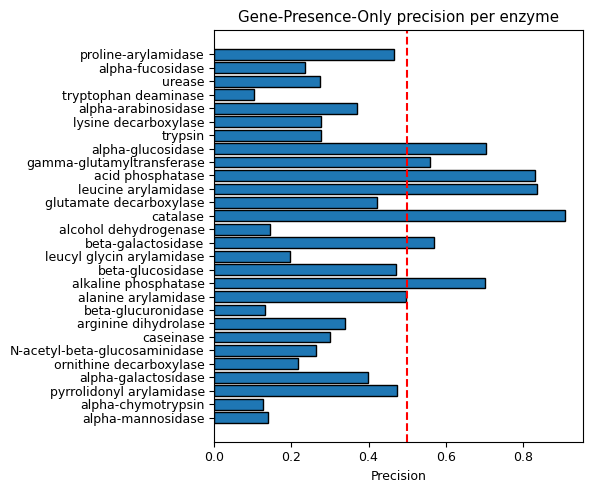

['alpha-mannosidase',
 'alpha-chymotrypsin',
 'pyrrolidonyl arylamidase',
 'alpha-galactosidase',
 'ornithine decarboxylase',
 'N-acetyl-beta-glucosaminidase',
 'caseinase',
 'arginine dihydrolase',
 'beta-glucuronidase',
 'alanine arylamidase',
 'beta-glucosidase',
 'leucyl glycin arylamidase',
 'alcohol dehydrogenase',
 'glutamate decarboxylase',
 'trypsin',
 'lysine decarboxylase',
 'alpha-arabinosidase',
 'tryptophan deaminase',
 'urease',
 'alpha-fucosidase',
 'proline-arylamidase']

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20})
plt.rcParams['font.family'] = 'Nimbus Sans'

precisions, f1s = [], []
for trait in final_df_f1.trait:
    num_pos, pos_available = r[trait]['positive']['count'], r[trait]['positive']['available']
    num_neg, neg_available = r[trait]['negative']['count'], r[trait]['negative']['available']
    precision, f1 = gene_presence_only_metrics(num_pos, pos_available, num_neg, neg_available)
    precisions.append(precision)
    f1s.append(f1)

df = final_df_f1
df["presence_only_precision"] = precisions
df["presence_only_F1"] = f1s


# traits below F1 = 0.5
bad_traits = df[df["presence_only_precision"] < 0.5]["trait"].tolist()

plt.rcParams.update({"font.size": 9})
fig, ax = plt.subplots(figsize=(6, 5))

ax.barh(df["trait"], df["presence_only_precision"], edgecolor="k")
ax.axvline(0.5, color="red", linestyle="--", linewidth=1.5)

ax.set_title("Gene-Presence-Only precision per enzyme")
ax.set_xlabel("Precision")
plt.tight_layout()
plt.savefig("/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/results/figures/figures_v2/fig2_panel_b.svg", dpi=300,bbox_inches='tight')
plt.show()

# bad_traits


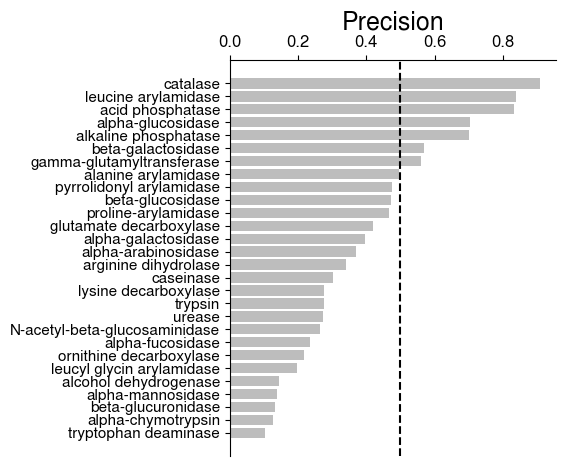

In [7]:
plt.rcParams.update({'font.size': 18})
plt.rcParams['font.family'] = 'Nimbus Sans'

precisions, f1s = [], []
for trait in final_df_f1.trait:
    num_pos, pos_available = r[trait]['positive']['count'], r[trait]['positive']['available']
    num_neg, neg_available = r[trait]['negative']['count'], r[trait]['negative']['available']
    precision, f1 = gene_presence_only_metrics(num_pos, pos_available, num_neg, neg_available)
    precisions.append(precision)
    f1s.append(f1)

df = final_df_f1.copy()
df["presence_only_precision"] = precisions
df["presence_only_F1"] = f1s

df = df.sort_values("presence_only_precision", ascending=False)
bad_traits = df[df["presence_only_precision"] < 0.5]["trait"].tolist()

fig, ax = plt.subplots(figsize=(6, 5))

ax.barh(
    df["trait"],
    df["presence_only_precision"],
    color="#bdbdbd"
)
ax.tick_params(axis="y", labelsize=11)
ax.tick_params(axis="x", labelsize=12)

ax.invert_yaxis()
ax.axvline(0.5, color="black", linestyle="--", linewidth=1.5)

# axis + frame styling
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['top'].set_visible(True)

# ax.set_title("Gene-presence-only precision per enzyme", pad=12)
ax.set_xlabel("Precision")

plt.tight_layout()
# plt.savefig(
#     "/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/results/figures/figures_v2/fig2_panel_b.svg",
#     dpi=300,
#     bbox_inches="tight"
# )
# plt.savefig(
#     "/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/results/figures/figures_v2/fig2_panel_b.pdf",
#     dpi=300,
#     bbox_inches="tight"
# )
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
#active_genomes/genomes without causal gene
# assuming df already loaded
#denom = (pos_available - pos_count) + (neg_available - neg_count)
#num = pos_available
for trait in final_df_f1.trait:
    num_pos, pos_available = r[trait]['positive']['count'],r[trait]['positive']['available']
    num_neg, neg_available = r[trait]['negative']['count'],r[trait]['negative']['available']
    acc, f1 = gene_presence_only_metrics(num_pos, pos_available, num_neg, neg_available)


plt.rcParams.update({'font.size': 9})
fig, ax = plt.subplots(figsize=(6, 5))
ax.barh(df["trait"], df["pct_active"], edgecolor='k')
ax.set_xlabel("% genomes with enzyme activity")
plt.tight_layout()
plt.show()

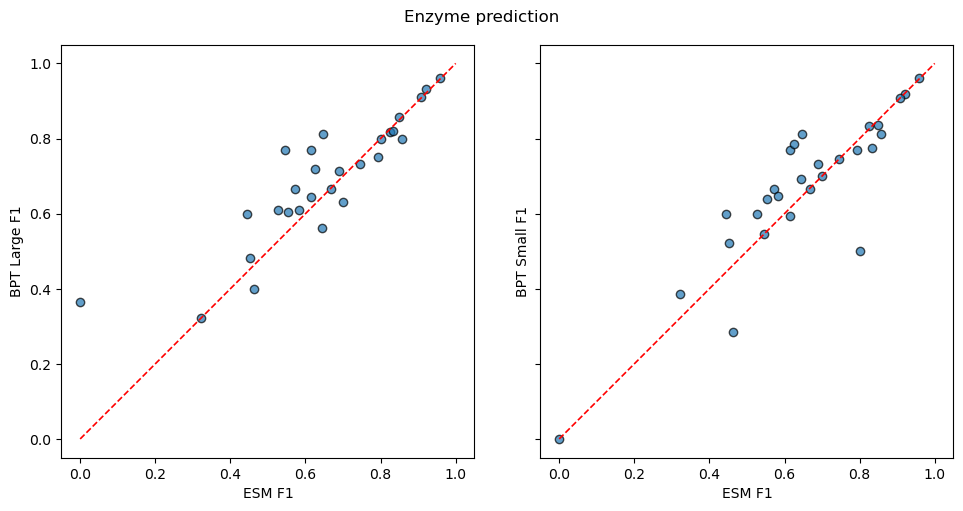

In [24]:
fig, ax = plt.subplots(1,2,figsize=(10,5),sharex=True,sharey=True)
for i,(y,t) in enumerate([('blm_big_F1','Large'),('blm_small_F1','Small')]):
    ax[i].scatter(final_df_f1['esm_F1'],final_df_f1[y],alpha=0.7,edgecolor='k')
    ax[i].plot([0,1],[0,1],'r--',lw=1.2)
    ax[i].set(xlabel="ESM F1",ylabel=f"BPT {t} F1",aspect='equal')
fig.suptitle("Enzyme prediction")
plt.tight_layout(); plt.show()


Processing columns:   0%|          | 0/1 [00:00<?, ?it/s]

Searching ECs for glutamate decarboxylase:   0%|          | 0/168 [00:00<?, ?it/s]

glutamate decarboxylase | +: 16/17, -: 22/151 | usable: False


Building dataset for blm_big 1:   0%|          | 0/16 [00:00<?, ?it/s]

Building dataset for blm_big 0:   0%|          | 0/22 [00:00<?, ?it/s]

Building dataset for blm_small 1:   0%|          | 0/16 [00:00<?, ?it/s]

Building dataset for blm_small 0:   0%|          | 0/22 [00:00<?, ?it/s]

Building dataset for esm 1:   0%|          | 0/16 [00:00<?, ?it/s]

Building dataset for esm 0:   0%|          | 0/22 [00:00<?, ?it/s]

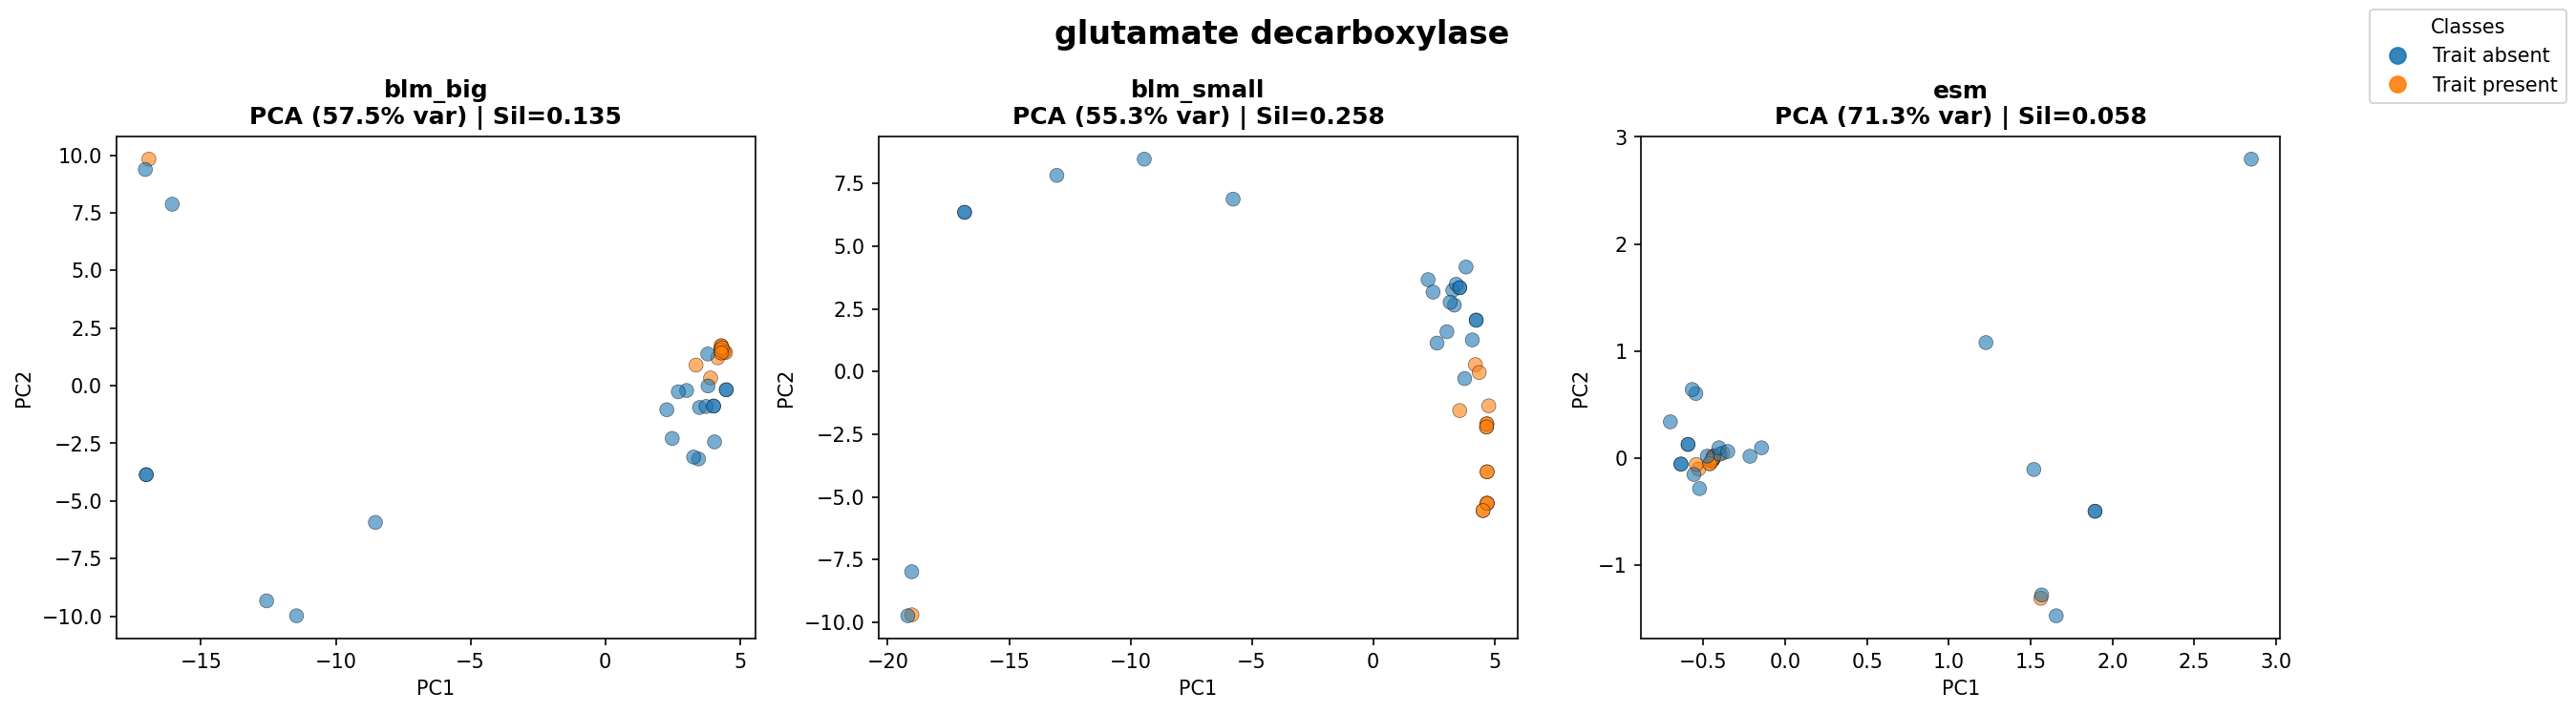

In [17]:
trait = "glutamate decarboxylase"
layers = [0, 1, 0]
models = ['blm_big', 'blm_small', 'esm']

fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5), dpi=150)
if len(models) == 1:
    axes = [axes]

r_ = run_ec_search(enzyme_df, ec_dict, specific_col=trait)

# Shared color map
color_map = {0: plt.cm.tab10(0), 1: plt.cm.tab10(0.1)}

for i, (model, layer) in enumerate(zip(models, layers)):
    get_layer, n_layers, [num_pos, num_neg] = cluster_all_layers(r_, trait, model)
    e, l = get_layer(layer)
    
    sil_pca, var_exp = plot_embeddings(e, l, trait=trait, model_name=model, 
                                       pca_only=True, plot=True, ax=axes[i], 
                                       color_map=color_map, balance=False)
    
    # Now set title with all info
    axes[i].set_title(f"{model}\nPCA ({var_exp:.1f}% var) | Sil={sil_pca:.3f}", 
                     fontsize=12, fontweight="bold")

# Shared legend
handles = [plt.Line2D([], [], marker='o', linestyle='', color=color_map[lbl],
                     alpha=0.9, markersize=8, 
                     label=f"Trait {'present' if lbl==1 else 'absent'}")
          for lbl in [0, 1]]
fig.legend(handles=handles, loc="upper right", title="Classes", fontsize=10)
plt.suptitle(trait, fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

In [18]:
r_

{'glutamate decarboxylase': {'usable': False,
  'positive': {'count': 16,
   'available': 17,
   'gids': ['GCF_014131755',
    'GCF_000012845',
    'GCF_000025985',
    'GCF_000512915',
    'GCF_000807675',
    'GCF_001314995',
    'GCF_002222615',
    'GCF_000025985',
    'GCF_014131755',
    'GCF_014131755',
    'GCF_025148635',
    'GCF_025147325',
    'GCF_002222615',
    'GCF_001314995',
    'GCF_025146565',
    'GCF_000012845'],
   'p_acc': ['WP_011108358.1',
    'WP_005857385.1',
    'WP_005784276.1',
    'WP_025279340.1',
    'WP_038354114.1',
    'WP_004296269.1',
    'WP_005675508.1',
    'WP_005784276.1',
    'WP_011108358.1',
    'WP_011108358.1',
    'WP_027201370.1',
    'WP_005653335.1',
    'WP_005675508.1',
    'WP_004296269.1',
    'WP_004288413.1',
    'WP_005857385.1']},
  'negative': {'count': 22,
   'available': 151,
   'gids': ['GCF_000013285',
    'GCF_000012825',
    'GCF_000014465',
    'GCF_000017025',
    'GCF_000024265',
    'GCF_000310065',
    'GCF_000940

In [88]:
#CODE FOR GENERATING ALIGNMENTS
import numpy as np
from itertools import combinations
import gffpandas.gffpandas as gffpd

def align_lists(list1, list2, match_score=2, mismatch_penalty=-1, gap_penalty=-1):
    """
    Align two lists using Needleman-Wunsch global alignment algorithm.
    Elements are aligned based on exact identity.
    
    Parameters:
    - list1, list2: Lists of strings to align
    - match_score: Score for matching elements (default: 2)
    - mismatch_penalty: Penalty for mismatched elements (default: -1)
    - gap_penalty: Penalty for gaps (default: -1)
    
    Returns:
    - aligned_list1: List with gaps ('-') inserted
    - aligned_list2: List with gaps ('-') inserted
    - score: Alignment score
    """
    n, m = len(list1), len(list2)
    
    # Initialize scoring matrix
    score_matrix = np.zeros((n + 1, m + 1))
    
    # Initialize gap penalties
    for i in range(n + 1):
        score_matrix[i][0] = gap_penalty * i
    for j in range(m + 1):
        score_matrix[0][j] = gap_penalty * j
    
    # Fill the scoring matrix
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            # Check if elements match (exact identity)
            if list1[i-1] == list2[j-1]:
                match = score_matrix[i-1][j-1] + match_score
            else:
                match = score_matrix[i-1][j-1] + mismatch_penalty
            
            # Consider gap in list2
            delete = score_matrix[i-1][j] + gap_penalty
            
            # Consider gap in list1
            insert = score_matrix[i][j-1] + gap_penalty
            
            score_matrix[i][j] = max(match, delete, insert)
    
    # Traceback to get alignment
    aligned_list1 = []
    aligned_list2 = []
    
    i, j = n, m
    while i > 0 or j > 0:
        current_score = score_matrix[i][j]
        
        if i > 0 and j > 0:
            if list1[i-1] == list2[j-1]:
                diagonal_score = score_matrix[i-1][j-1] + match_score
            else:
                diagonal_score = score_matrix[i-1][j-1] + mismatch_penalty
        else:
            diagonal_score = float('-inf')
        
        up_score = score_matrix[i-1][j] + gap_penalty if i > 0 else float('-inf')
        left_score = score_matrix[i][j-1] + gap_penalty if j > 0 else float('-inf')
        
        if i > 0 and j > 0 and current_score == diagonal_score:
            # Match or mismatch
            aligned_list1.insert(0, list1[i-1])
            aligned_list2.insert(0, list2[j-1])
            i -= 1
            j -= 1
        elif i > 0 and current_score == up_score:
            # Gap in list2
            aligned_list1.insert(0, list1[i-1])
            aligned_list2.insert(0, '-')
            i -= 1
        else:
            # Gap in list1
            aligned_list1.insert(0, '-')
            aligned_list2.insert(0, list2[j-1])
            j -= 1
    
    return aligned_list1, aligned_list2, score_matrix[n][m]


def align_multiple_lists(lists, match_score=2, mismatch_penalty=-1, gap_penalty=-1):
    """
    Align multiple lists using progressive alignment strategy.
    
    Progressive alignment works by:
    1. Aligning the first two lists
    2. Aligning each subsequent list to the growing alignment
    
    Parameters:
    - lists: List of lists to align (3 or more lists)
    - match_score: Score for matching elements (default: 2)
    - mismatch_penalty: Penalty for mismatched elements (default: -1)
    - gap_penalty: Penalty for gaps (default: -1)
    
    Returns:
    - aligned_lists: List of aligned lists with gaps inserted
    - total_score: Sum of pairwise alignment scores
    """
    if len(lists) < 2:
        return lists, 0
    
    if len(lists) == 2:
        aligned1, aligned2, score = align_lists(lists[0], lists[1], match_score, mismatch_penalty, gap_penalty)
        return [aligned1, aligned2], score
    
    # Start with first two lists
    aligned1, aligned2, total_score = align_lists(lists[0], lists[1], match_score, mismatch_penalty, gap_penalty)
    aligned_lists = [aligned1, aligned2]
    
    # Progressively add each remaining list
    for i in range(2, len(lists)):
        new_list = lists[i]
        
        # Align new list to the consensus/first aligned list
        consensus = aligned_lists[0]
        new_aligned, consensus_aligned, score = align_lists(
            [x for x in consensus if x != '-'],  # Remove gaps for alignment
            new_list,
            match_score,
            mismatch_penalty,
            gap_penalty
        )
        
        total_score += score
        
        # Map gaps back to all previously aligned lists
        gap_positions = []
        consensus_idx = 0
        
        for pos, elem in enumerate(consensus_aligned):
            if consensus_idx < len(consensus):
                while consensus_idx < len(consensus) and consensus[consensus_idx] == '-':
                    gap_positions.append((pos, 'existing'))
                    consensus_idx += 1
            
            if elem == '-' and consensus_idx < len(consensus):
                gap_positions.append((pos, 'new'))
            elif elem != '-':
                consensus_idx += 1
        
        # Insert gaps in all previously aligned lists
        for j in range(len(aligned_lists)):
            updated_list = []
            orig_idx = 0
            new_idx = 0
            
            for pos in range(len(new_aligned)):
                if new_aligned[pos] == '-':
                    # New gap needed
                    updated_list.append('-')
                else:
                    # Copy from original alignment, skipping its gaps
                    while orig_idx < len(aligned_lists[j]) and aligned_lists[j][orig_idx] == '-':
                        if new_idx < len(new_aligned) and new_aligned[new_idx] != '-':
                            updated_list.append('-')
                            new_idx += 1
                        orig_idx += 1
                    
                    if orig_idx < len(aligned_lists[j]):
                        updated_list.append(aligned_lists[j][orig_idx])
                        orig_idx += 1
                    new_idx += 1
            
            # Simpler approach: just ensure same length
            while len(updated_list) < len(new_aligned):
                updated_list.append('-')
            
            aligned_lists[j] = updated_list[:len(new_aligned)]
        
        # Add the new aligned list
        aligned_lists.append(new_aligned)
    
    # Ensure all lists are the same length
    max_len = max(len(lst) for lst in aligned_lists)
    for i in range(len(aligned_lists)):
        while len(aligned_lists[i]) < max_len:
            aligned_lists[i].append('-')
    
    return aligned_lists, total_score


def align_multiple_lists_simple(lists, match_score=2, mismatch_penalty=-1, gap_penalty=-1):
    """
    Simpler multiple alignment: align each list to the first one independently,
    then merge gap positions.
    
    This is faster but may not be optimal. Good for quick alignments.
    """
    if len(lists) < 2:
        return lists, 0
    
    reference = lists[0]
    all_alignments = [[x for x in reference]]  # Start with reference
    total_score = 0
    
    # Align each list to the reference
    pairwise_alignments = []
    for i in range(1, len(lists)):
        aligned_ref, aligned_list, score = align_lists(reference, lists[i], match_score, mismatch_penalty, gap_penalty)
        pairwise_alignments.append((aligned_ref, aligned_list))
        total_score += score
    
    # Find all unique gap positions across all alignments
    max_length = max(len(pairwise_alignments[i][0]) for i in range(len(pairwise_alignments)))
    
    # Build the final alignment by merging gap patterns
    final_alignments = []
    
    # Process reference
    final_ref = []
    for pair_ref, _ in pairwise_alignments:
        if len(final_ref) == 0:
            final_ref = pair_ref[:]
        else:
            # Merge gaps
            merged = []
            idx = 0
            for elem in pair_ref:
                if elem == '-':
                    merged.append('-')
                else:
                    while idx < len(final_ref) and final_ref[idx] == '-':
                        merged.append('-')
                        idx += 1
                    if idx < len(final_ref):
                        merged.append(final_ref[idx])
                        idx += 1
            final_ref = merged
    
    final_alignments.append(final_ref)
    
    # Process each other list
    for pair_ref, pair_list in pairwise_alignments:
        aligned = []
        ref_idx = 0
        for i in range(len(final_ref)):
            if ref_idx < len(pair_ref) and pair_ref[ref_idx] == final_ref[i]:
                aligned.append(pair_list[ref_idx])
                ref_idx += 1
            elif final_ref[i] == '-':
                aligned.append('-')
            else:
                while ref_idx < len(pair_ref) and pair_ref[ref_idx] == '-':
                    ref_idx += 1
                if ref_idx < len(pair_list):
                    aligned.append(pair_list[ref_idx])
                    ref_idx += 1
                else:
                    aligned.append('-')
        
        final_alignments.append(aligned)
    
    # Ensure all same length
    max_len = max(len(lst) for lst in final_alignments)
    for i in range(len(final_alignments)):
        while len(final_alignments[i]) < max_len:
            final_alignments[i].append('-')
    
    return final_alignments, total_score


def print_alignment(list1, list2, aligned_list1, aligned_list2, score):
    """Pretty print pairwise alignment."""
    print(f"Original List 1: {list1}")
    print(f"Original List 2: {list2}")
    print(f"\nAlignment Score: {score}")
    print("\nAligned sequences:")
    print("List 1:", aligned_list1)
    print("List 2:", aligned_list2)
    print("\nVisual alignment:")
    
    # Create match indicators
    match_line = []
    for a, b in zip(aligned_list1, aligned_list2):
        if a == b and a != '-':
            match_line.append('|')  # Match
        elif a == '-' or b == '-':
            match_line.append(' ')  # Gap
        else:
            match_line.append('x')  # Mismatch
    
    # Calculate max width for formatting
    max_width = max(len(str(x)) for x in aligned_list1 + aligned_list2)
    
    # Print aligned elements
    line1 = ' '.join(str(x).ljust(max_width) for x in aligned_list1)
    line2 = ' '.join(m.ljust(max_width) for m in match_line)
    line3 = ' '.join(str(x).ljust(max_width) for x in aligned_list2)
    
    print(line1)
    print(line2)
    print(line3)


def print_multiple_alignment(original_lists, aligned_lists, score):
    """Pretty print multiple sequence alignment."""
    print("Original Lists:")
    for i, lst in enumerate(original_lists, 1):
        print(f"  List {i}: {lst}")
    
    print(f"\nTotal Alignment Score: {score}")
    print("\nAligned sequences:")
    
    # Calculate max width for formatting
    max_width = max(len(str(x)) for aligned_list in aligned_lists for x in aligned_list)
    
    for i, aligned_list in enumerate(aligned_lists, 1):
        line = ' '.join(str(x).ljust(max_width) for x in aligned_list)
        print(f"List {i}: {line}")
    
    print("\nConservation:")
    # Show conservation (* = all match, : = some match, . = no match)
    conservation = []
    for pos in range(len(aligned_lists[0])):
        column = [aligned_lists[i][pos] for i in range(len(aligned_lists))]
        non_gaps = [x for x in column if x != '-']
        
        if len(non_gaps) == 0:
            conservation.append(' ')
        elif len(set(non_gaps)) == 1:
            conservation.append('*')  # Fully conserved
        elif len(set(non_gaps)) < len(non_gaps):
            conservation.append(':')  # Partially conserved
        else:
            conservation.append('.')  # Not conserved
    
    print(' ' * 8 + ' '.join(c.ljust(max_width) for c in conservation))
    
def save_multiple_alignment(original_lists, aligned_lists, score, output_file="alignment.txt"):
    """Save multiple sequence alignment to a text file."""
    with open('/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/enzyme_task/results/alignments/'+output_file, 'w') as f:
        f.write("Original Lists:\n")
        for i, lst in enumerate(original_lists, 1):
            f.write(f"  List {i}: {lst}\n")
        
        f.write(f"\nTotal Alignment Score: {score}\n")
        f.write("\nAligned sequences:\n")
        
        # Calculate max width for formatting
        max_width = max(len(str(x)) for aligned_list in aligned_lists for x in aligned_list)
        
        for i, aligned_list in enumerate(aligned_lists, 1):
            line = ' '.join(str(x).ljust(max_width) for x in aligned_list)
            f.write(f"List {i}: {line}\n")
        
        f.write("\nConservation:\n")
        # Show conservation (* = all match, : = some match, . = no match)
        conservation = []
        for pos in range(len(aligned_lists[0])):
            column = [aligned_lists[i][pos] for i in range(len(aligned_lists))]
            non_gaps = [x for x in column if x != '-']
            
            if len(non_gaps) == 0:
                conservation.append(' ')
            elif len(set(non_gaps)) == 1:
                conservation.append('*')  # Fully conserved
            elif len(set(non_gaps)) < len(non_gaps):
                conservation.append(':')  # Partially conserved
            else:
                conservation.append('.')  # Not conserved
        
        f.write(' ' * 8 + ' '.join(c.ljust(max_width) for c in conservation) + '\n')
    
    print(f"Alignment saved to {output_file}")
    
def save_alignment_to_csv(aligned_lists, output_file="alignment.csv", include_conservation=True):
    """
    Save multiple sequence alignment to CSV format.
    Each row is a list, each column is a position in the alignment.
    
    Parameters:
    - aligned_lists: List of aligned lists (with gaps)
    - output_file: Output filename (default: alignment.csv)
    - include_conservation: Add conservation row at bottom (default: True)
    """
    import csv
    
    with open('/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/enzyme_task/results/alignments/'+output_file, 'w', newline='') as f:
        writer = csv.writer(f)
        
        # Write header (position numbers)
        max_len = len(aligned_lists[0])
        header = ['List'] + [f"Pos_{i+1}" for i in range(max_len)]
        writer.writerow(header)
        
        # Write each aligned list
        for i, aligned_list in enumerate(aligned_lists, 1):
            row = [f"List_{i}"] + aligned_list
            writer.writerow(row)
        
        # Add conservation row
        if include_conservation:
            conservation = ['Conservation']
            for pos in range(max_len):
                column = [aligned_lists[i][pos] for i in range(len(aligned_lists))]
                non_gaps = [x for x in column if x != '-']
                
                if len(non_gaps) == 0:
                    conservation.append('')
                elif len(set(non_gaps)) == 1:
                    conservation.append('*')  # Fully conserved
                elif len(set(non_gaps)) < len(non_gaps):
                    conservation.append(':')  # Partially conserved
                else:
                    conservation.append('.')  # Not conserved
            
            writer.writerow(conservation)
    
    print(f"Alignment saved to {output_file}")


def save_alignment_to_tsv(aligned_lists, output_file="alignment.tsv", include_conservation=True):
    """
    Save multiple sequence alignment to TSV (tab-separated) format.
    Each row is a list, each column is a position in the alignment.
    
    Parameters:
    - aligned_lists: List of aligned lists (with gaps)
    - output_file: Output filename (default: alignment.tsv)
    - include_conservation: Add conservation row at bottom (default: True)
    """
    with open('/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/enzyme_task/results/alignments/'+output_file, 'w') as f:
        # Write header (position numbers)
        max_len = len(aligned_lists[0])
        header = 'List\t' + '\t'.join([f"Pos_{i+1}" for i in range(max_len)])
        f.write(header + '\n')
        
        # Write each aligned list
        for i, aligned_list in enumerate(aligned_lists, 1):
            row = f"List_{i}\t" + '\t'.join(aligned_list)
            f.write(row + '\n')
        
        # Add conservation row
        if include_conservation:
            conservation = ['Conservation']
            for pos in range(max_len):
                column = [aligned_lists[i][pos] for i in range(len(aligned_lists))]
                non_gaps = [x for x in column if x != '-']
                
                if len(non_gaps) == 0:
                    conservation.append('')
                elif len(set(non_gaps)) == 1:
                    conservation.append('*')  # Fully conserved
                elif len(set(non_gaps)) < len(non_gaps):
                    conservation.append(':')  # Partially conserved
                else:
                    conservation.append('.')  # Not conserved
            
            row = 'Conservation\t' + '\t'.join(conservation)
            f.write(row + '\n')
    
    print(f"Alignment saved to {output_file}")
    


def generate_order(gid):
    table_path = "/orange/juannanzhou/bacteria_genome/protein_faa_files/gff3_files/"+gid+".gff"
    annotation = gffpd.read_gff3(table_path)
    attr_to_columns = annotation.attributes_to_columns()
    # sorted_table = attr_to_columns.sort_values(by='end').protein_id.dropna().drop_duplicates()
    sorted_table = pd.read_csv("/orange/juannanzhou/bacteria_genome/protein_faa_files/order_tables/"+gid+"_order.txt",\
             sep=' ')
    return sorted_table, attr_to_columns

def get_order(gid, max_len=2250):
    #make sure we read only those proteins whose length is less than 2250
    fasta_path = f'/orange/juannanzhou/bacteria_genome/protein_faa_files/sorted_protein_faa_files/sorted_{gid}.faa'
    ids = []
    try:
        with open(fasta_path) as f:
            cur_id, cur_seq = None, []
            for line in f:
                line = line.strip()
                if line.startswith(">"):
                    # flush previous record
                    if cur_id is not None and len("".join(cur_seq)) <= max_len:
                        ids.append(cur_id)
                    cur_id = line[1:].split()[0]
                    cur_seq = []
                else:
                    cur_seq.append(line)
            # flush last record
            if cur_id is not None and len("".join(cur_seq)) <= max_len:
                ids.append(cur_id)
    except Exception as e:
        print(f"Error reading {fasta_path}: {e}")
        return None
    return ids

def get_index_of_poi(genome_name, goi_list, max_len=2250):
    """
    Map protein IDs (goi_list) -> index in genome's ordered FASTA (filtered by length<=max_len).
    start: 0 for 0-based, 1 for 1-based indices.
    """
    ids = get_order(genome_name, max_len=max_len)  # returns list of protein IDs in order
    # print('ids in poi2', ids)
    if ids is None:
        return {goi: None for goi in goi_list}
    pid_vs_idx = {int(i): v for i, v in enumerate(ids)}
    # id2idx = {pid: i + start for i, pid in enumerate(ids)}
    # return {goi: id2idx.get(goi, None) for goi in goi_list}
    return {goi: pid_vs_idx.get(goi, None) for goi in goi_list}

def get_gene_names(att,genome_name = "GCF_000005845",result = [99,100,101], colm='gene'):
    goi = get_index_of_poi(genome_name, result)
    g_pids = list(goi.values())
    return list(att[(att['protein_id'].isin(g_pids)) & (att['gbkey'] == 'CDS')][colm]), g_pids

def get_ec_poi_and_products(gid, index, window=5):
    t, att = generate_order(gid)
    products, pids = get_gene_names(att, genome_name=gid, result =range(index-window, index+window), colm = 'product')
    return products

In [90]:
r_=r

In [92]:
pos_products = []
neg_products = []
for i in range(r_['alpha-mannosidase']['positive']['count']):
    gid = r_['alpha-mannosidase']['positive']['gids'][i]
    pid = r_['alpha-mannosidase']['positive']['p_acc'][i]
    try:
        _, idx = get_index(gid, pid)
        pos_products.append(get_ec_poi_and_products(gid, idx, window=2))
    except:
        continue
for i in range(r_['alpha-mannosidase']['negative']['count']):
    gid = r_['alpha-mannosidase']['negative']['gids'][i]
    pid = r_['alpha-mannosidase']['negative']['p_acc'][i]
    try:
        _, idx = get_index(gid, pid)
        neg_products.append(get_ec_poi_and_products(gid, idx, window=2))
    except:
        continue

In [93]:
neg_products = [lst for lst in neg_products if 'alpha-mannosidase' in lst]
lists = neg_products

aligned, score = align_multiple_lists_simple(lists)
print(score)
# save_multiple_alignment(lists, aligned, score, 'pos_products.txt')
save_alignment_to_csv(aligned, "neg_products_alpha_mannosidase.csv")

-48.0
Alignment saved to neg_products_alpha_mannosidase.csv


In [94]:
pos_products = [lst for lst in pos_products if 'alpha-mannosidase' in lst]
lists = pos_products# + [list(reversed(p)) for p in pos_products]

aligned, score = align_multiple_lists_simple(lists)
print(score)
# save_multiple_alignment(lists, aligned, score, 'pos_products.txt')
save_alignment_to_csv(aligned, "pos_products_alpha_mannosidas.csv")

-8.0
Alignment saved to pos_products_alpha_mannosidas.csv


In [11]:
plt.rcParams.update({'font.size': 24})
plt.rcParams['font.family'] = 'Nimbus Sans'

def plot_trait_group_comparison(df, s_fp, gap=8, bar_width=1, thresh=0.5, show_errbars=False):
    # Clean and prepare data
    df = df[df.presence_only_precision <= thresh].copy()
    print(len(df.trait))
    
    models = [
        "presence_only_F1",
        "esm_F1",
        "blm_small_F1",
        "blm_big_F1"
    ]
    
    std_map = {
        "presence_only_F1": None,
        "esm_F1": "esm_F1_std",
        "blm_small_F1": "blm_small_F1_std",
        "blm_big_F1": "blm_big_F1_std"
    }
    
    blm_models = ["blm_small_F1", "blm_big_F1"]

    # sorting
    df["best_blm"] = df[blm_models].max(axis=1)
    df["delta_blm_vs_esm"] = df["best_blm"] - df["esm_F1"]
    df_sorted = df.sort_values("delta_blm_vs_esm", ascending=False)

    x = [i * gap for i in range(len(df_sorted))]

    label_map = {
        "presence_only_F1": "presence-only",
        "esm_F1": "ESM",
        "blm_small_F1": r'BacPT$_{\text{small}}$',
        "blm_big_F1": r'BacPT$_{\text{large}}$'
    }

    colors = {
        "presence_only_F1": "#cccccc",
        "esm_F1": "#555555",
        "blm_small_F1": "#A7C3E5",
        "blm_big_F1": "#5383C1"
    }

    fig, ax = plt.subplots(figsize=(20, 12))

    # Draw bars with clipped error bars
    for i, model in enumerate(models):
        yerr = None
        error_kw = None

        if show_errbars and std_map[model] is not None:
            means = df_sorted[model].values
            stds = df_sorted[std_map[model]].values

            capped = []
            for mean, std in zip(means, stds):
                upper = mean + std
                lower = mean - std

                # clip upper at 0.99
                if upper > 0.99:
                    std = 0.99 - mean

                # clip lower at 0.00
                if lower < 0.0:
                    std = mean - 0.0

                capped.append(std)

            yerr = capped
            error_kw = {"elinewidth": 1}

        ax.bar(
            [pos + i * bar_width for pos in x],
            df_sorted[model],
            yerr=yerr,
            width=bar_width,
            label=label_map[model],
            color=colors[model],
            capsize=0,
            ecolor="#aaaaaa" if yerr is not None else None,
            error_kw=error_kw
        )

    tick_positions = [pos + bar_width * (len(models)/2 - 0.5) for pos in x]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(df_sorted["trait"], rotation=45, ha='right')
    ax.set_ylabel("F1 Score")
    ax.set_ylim(0, 1)
    ax.set_title("Enzyme prediction")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0))
    ax.legend(loc='upper right',frameon=False)
    plt.savefig(f'{s_fp}.svg', dpi=300, bbox_inches="tight")
    plt.savefig(f'{s_fp}.pdf', dpi=300, bbox_inches="tight")

    plt.tight_layout()
    plt.show()


21


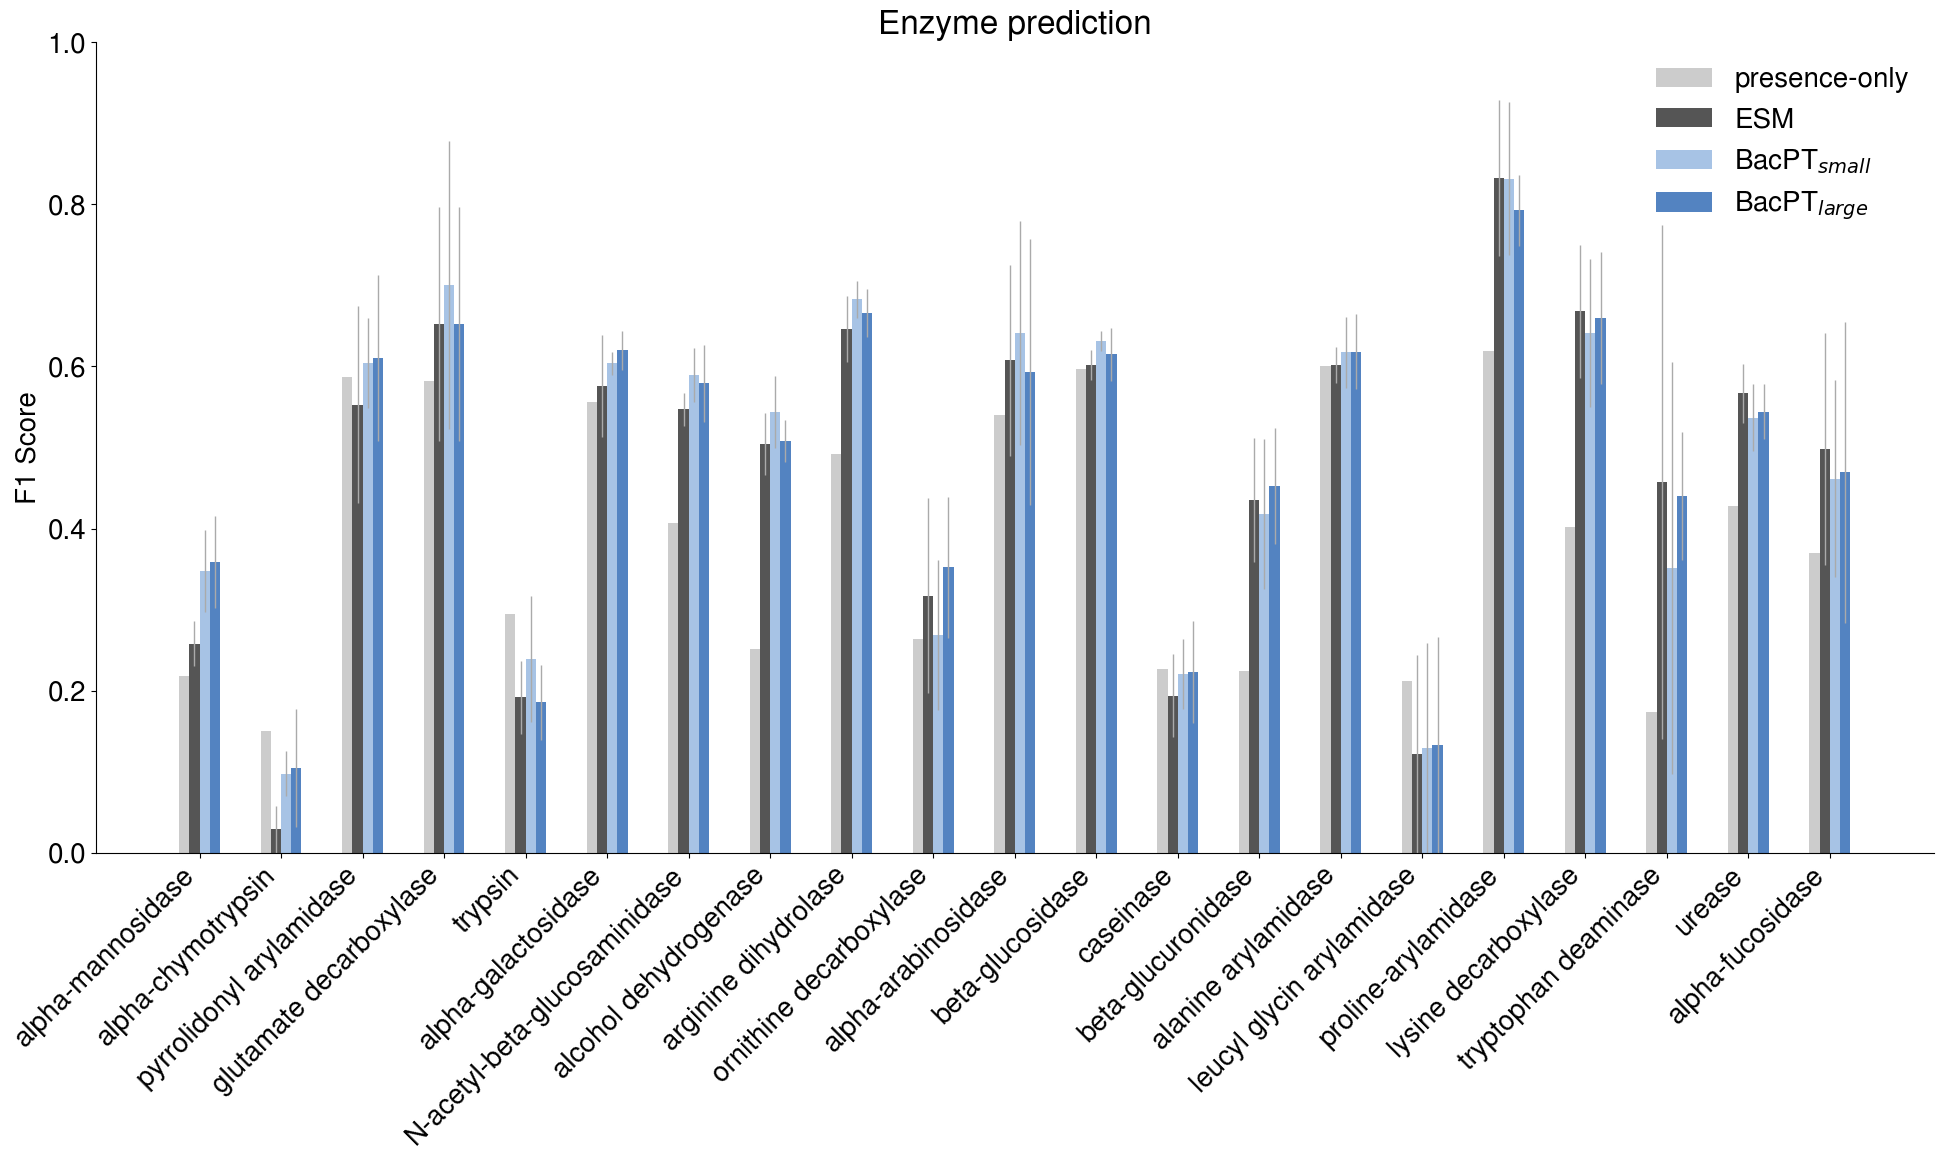

In [61]:
#df comes from Gene-presence-only precision per enzyme
plt.rcParams.update({'font.size': 24})
plt.rcParams['font.family'] = 'Nimbus Sans'
plot_trait_group_comparison(df, 
                            "/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/results/figures/figures_v2/fig2_panel_e",
                            thresh = 0.5, show_errbars=True)


21


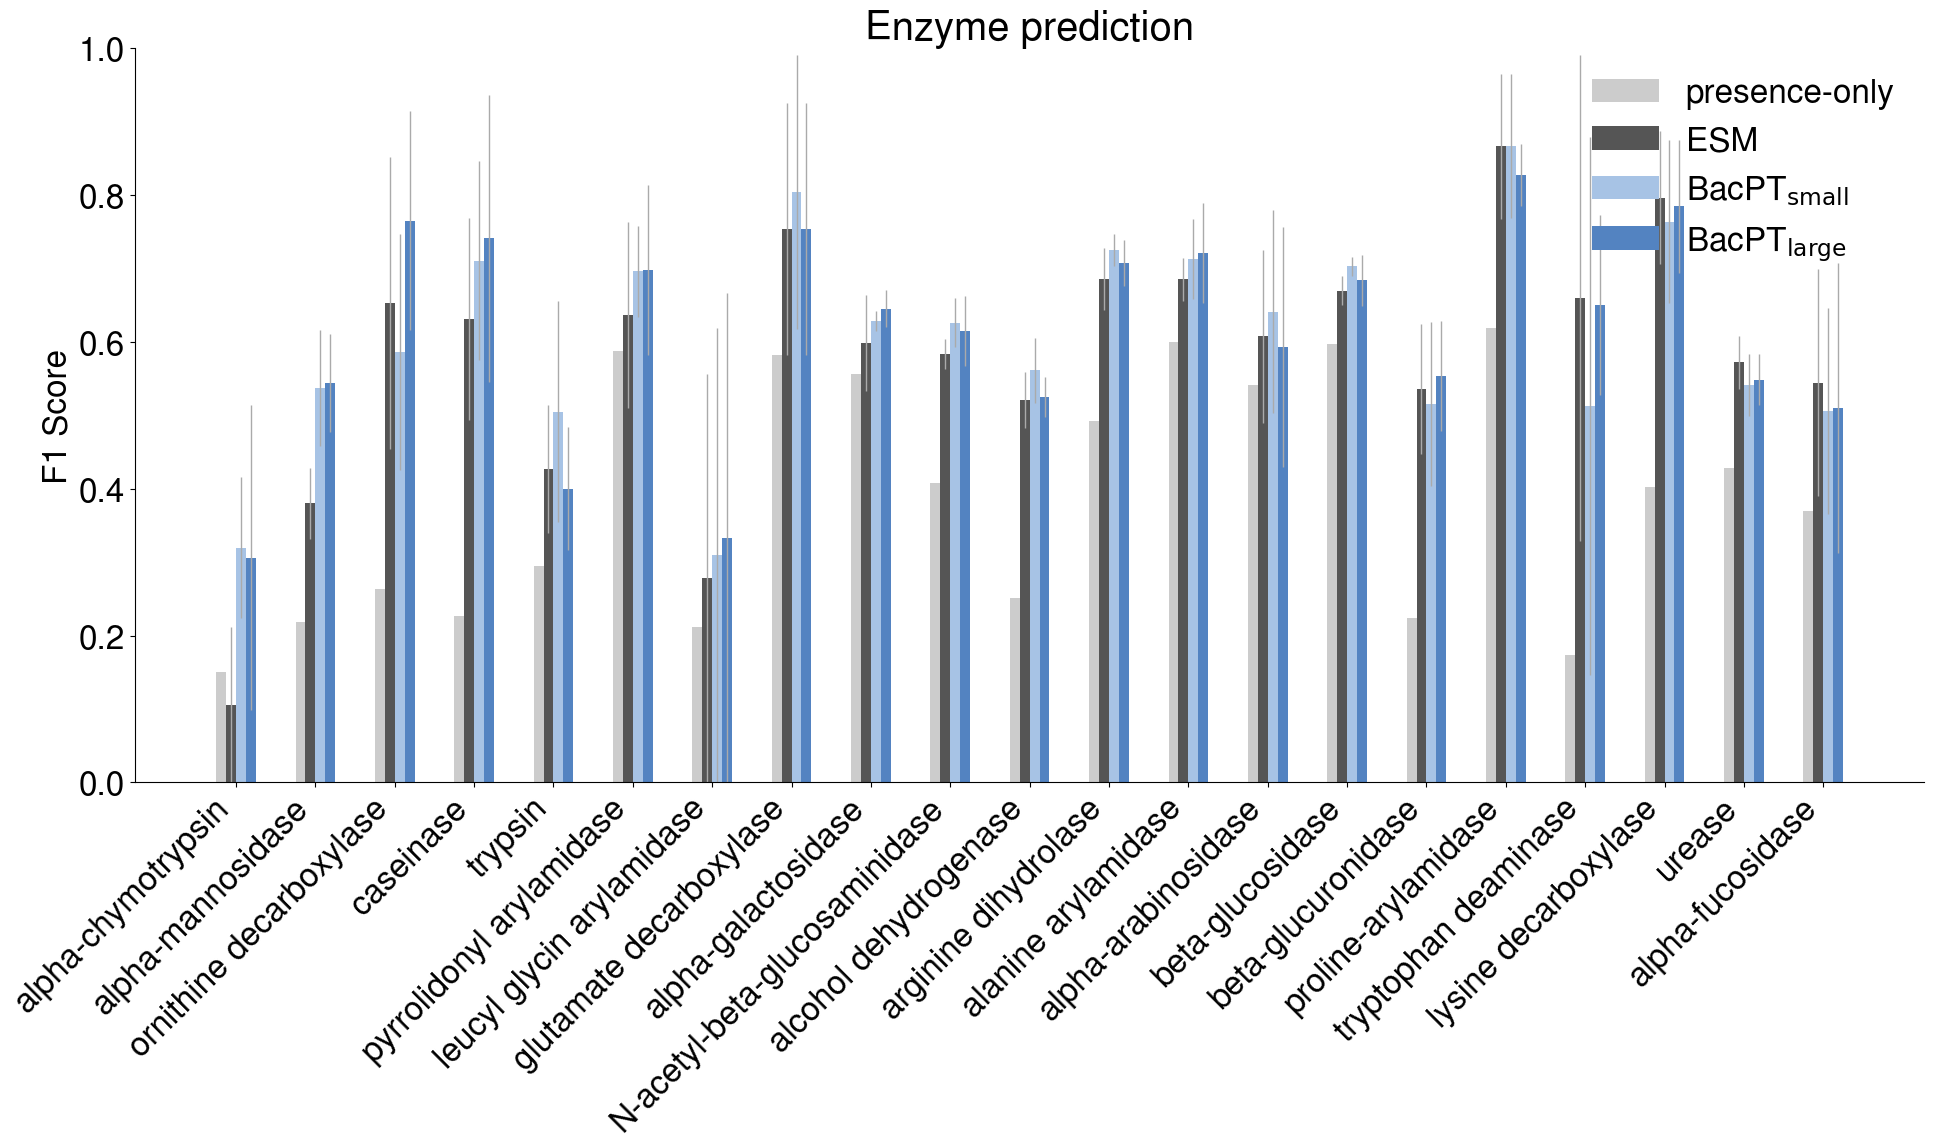

In [12]:
plt.rcParams.update({'font.size': 24})
plt.rcParams['font.family'] = 'Nimbus Sans'
plot_trait_group_comparison(df, 
                            "/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/results/figures/figures_v2/fig2_panel_d",
                            thresh = 0.5, show_errbars=True)


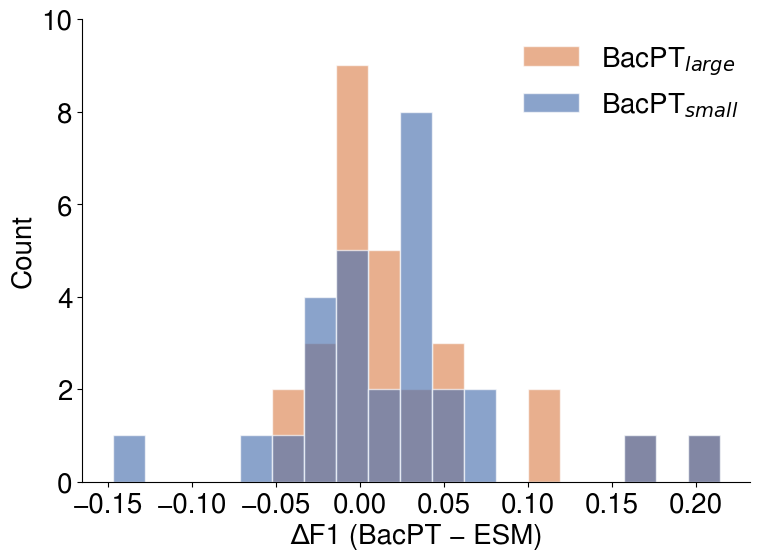

In [112]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20})
plt.rcParams['font.family'] = 'Nimbus Sans'

x_big   = df['blm_big_F1']   - df['esm_F1']
x_small = df['blm_small_F1'] - df['esm_F1']
s_fp = "/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/results/figures/figures_v2/fig2_panel_c_original"


bins = np.linspace(
    min(x_big.min(), x_small.min()),
    max(x_big.max(), x_small.max()),
    20
)

plt.figure(figsize=(8, 6))

plt.hist(
    x_big,
    bins=bins,
    color="#DD8452",  # seaborn salmon
    alpha=0.65,
    edgecolor="white",
    label=r'BacPT$_{large}$'
)

plt.hist(
    x_small,
    bins=bins,
    color="#4C72B0",  # seaborn blue
    alpha=0.65,
    edgecolor="white",
    label=r'BacPT$_{small}$'
)
plt.gca().spines[['top', 'right']].set_visible(False)

plt.xlabel("ΔF1 (BacPT − ESM)")
plt.ylabel("Count")
plt.legend(frameon=False, loc='upper right', bbox_to_anchor=(1.02, 1))
plt.ylim(0, 10)
plt.savefig(f'{s_fp}.svg', dpi=300, bbox_inches="tight")
plt.savefig(f'{s_fp}.pdf', dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()


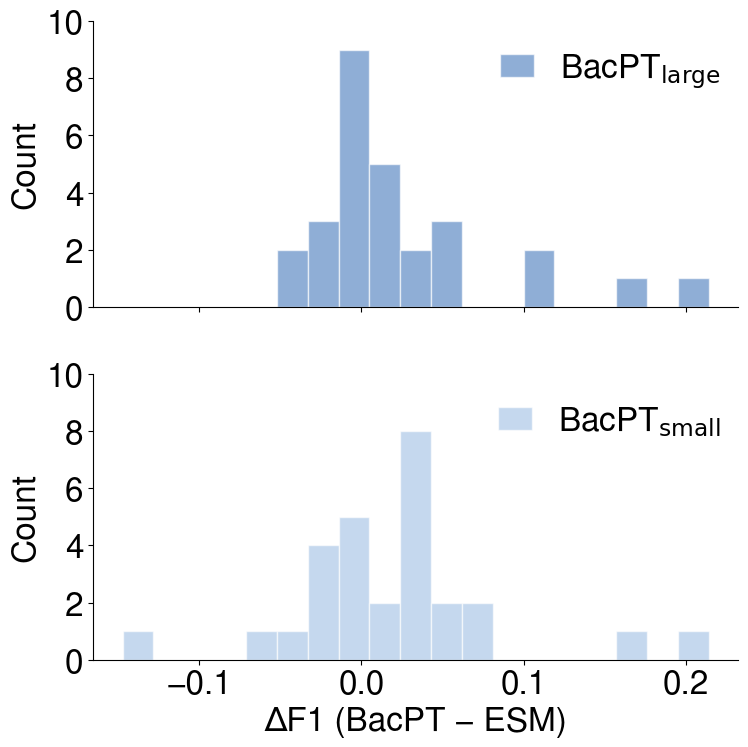

In [10]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 24})
plt.rcParams['font.family'] = 'Nimbus Sans'

big_model_color = '#5383C1'
small_model_color = '#A7C3E5'

x_big   = df['blm_big_F1']   - df['esm_F1']
x_small = df['blm_small_F1'] - df['esm_F1']

s_fp = "/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/results/figures/figures_v2/fig2_panel_c_original"

bins = np.linspace(
    min(x_big.min(), x_small.min()),
    max(x_big.max(), x_small.max()),
    20
)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(8, 8), sharex=True
)

# Top: BacPT_large
ax_top.hist(
    x_big,
    bins=bins,
    color=big_model_color,
    alpha=0.65,
    edgecolor="white",
    label=r'BacPT$_{\mathrm{large}}$'
)
ax_top.spines[['top', 'right']].set_visible(False)
ax_top.set_ylabel("Count")
ax_top.legend(frameon=False, loc='upper right', bbox_to_anchor=(1.02, 1), handlelength=1)
ax_top.set_ylim(0, 10)
ax_top.set_yticks(range(0, 11, 2))

# Bottom: BacPT_small
ax_bot.hist(
    x_small,
    bins=bins,
    color=small_model_color,
    alpha=0.65,
    edgecolor="white",
    label=r'BacPT$_{\mathrm{small}}$'
)
ax_bot.spines[['top', 'right']].set_visible(False)
ax_bot.set_xlabel("ΔF1 (BacPT − ESM)")
ax_bot.set_ylabel("Count")
ax_bot.legend(frameon=False, loc='upper right', bbox_to_anchor=(1.02, 1), handlelength=1)
ax_bot.set_ylim(0, 10)
ax_bot.set_yticks(range(0, 11, 2))

plt.tight_layout()
plt.savefig(f'{s_fp}.svg', dpi=300, bbox_inches="tight")
plt.savefig(f'{s_fp}.pdf', dpi=300, bbox_inches="tight")
plt.show()


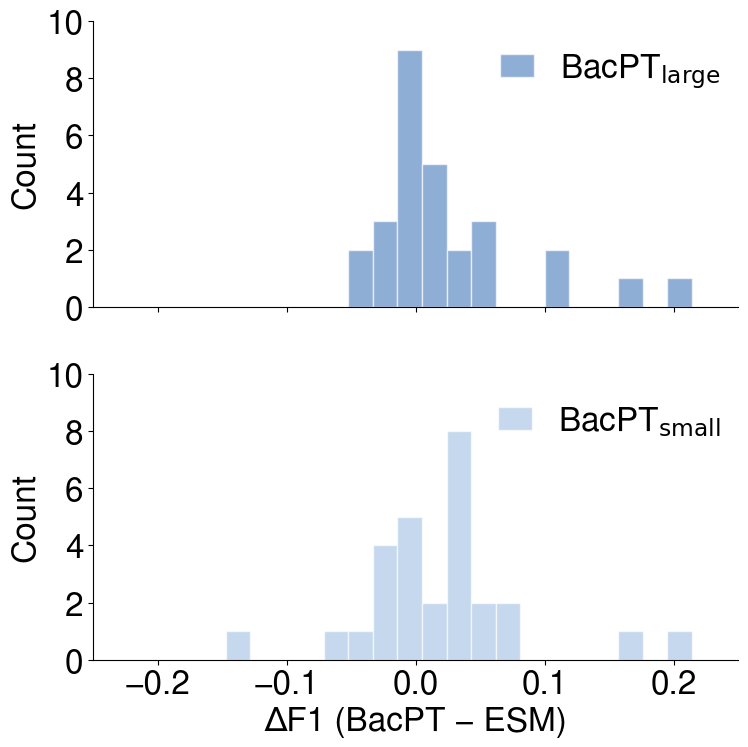

In [12]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 24})
plt.rcParams['font.family'] = 'Nimbus Sans'

big_model_color = '#5383C1'
small_model_color = '#A7C3E5'

x_big   = df['blm_big_F1']   - df['esm_F1']
x_small = df['blm_small_F1'] - df['esm_F1']

s_fp = "/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/results/figures/figures_v2/fig2_panel_c_original_changelimits"

bins = np.linspace(
    min(x_big.min(), x_small.min()),
    max(x_big.max(), x_small.max()),
    20
)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(8, 8), sharex=True
)

# Top: BacPT_large
ax_top.hist(
    x_big,
    bins=bins,
    color=big_model_color,
    alpha=0.65,
    edgecolor="white",
    label=r'BacPT$_{\mathrm{large}}$'
)
ax_top.spines[['top', 'right']].set_visible(False)
ax_top.set_ylabel("Count")
ax_top.legend(frameon=False, loc='upper right', bbox_to_anchor=(1.02, 1), handlelength=1)
ax_top.set_ylim(0, 10)
ax_top.set_xlim(-0.25, 0.25)
ax_top.set_yticks(range(0, 11, 2))

# Bottom: BacPT_small
ax_bot.hist(
    x_small,
    bins=bins,
    color=small_model_color,
    alpha=0.65,
    edgecolor="white",
    label=r'BacPT$_{\mathrm{small}}$'
)
ax_bot.spines[['top', 'right']].set_visible(False)
ax_bot.set_xlabel("ΔF1 (BacPT − ESM)")
ax_bot.set_ylabel("Count")
ax_bot.legend(frameon=False, loc='upper right', bbox_to_anchor=(1.02, 1), handlelength=1)
ax_bot.set_ylim(0, 10)
ax_bot.set_xlim(-0.25, 0.25)
ax_bot.set_yticks(range(0, 11, 2))

plt.tight_layout()
plt.savefig(f'{s_fp}.svg', dpi=300, bbox_inches="tight")
plt.savefig(f'{s_fp}.pdf', dpi=300, bbox_inches="tight")
plt.show()
